# 03f — Persistence Sensitivity: **2 vs 3 vs 4 pentads below P20**

This experiment changes only the required number of **initial consecutive pentads below P20**.

- `P2` = 2 pentads;
- `P3` = 3 pentads, existing `M2A` benchmark;
- `P4` = 4 pentads.

Held fixed:
- P40→P20;
- maximum onset = 5 pentads;
- mean decline ≥5 pp/pentad;
- strict monotonic onset;
- minimum total duration = 4 intervals;
- recovery = 1 pentad ≥P20.

The goal is not to find the variant with the “best-looking” result. The output is the sensitivity itself.


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
from scipy import stats

try:
    from dask.diagnostics import ProgressBar
except Exception:
    ProgressBar = None

warnings.filterwarnings("once")

RZSM_DIR = Path(
    r"D:\ERA5_LAND\output_rzsm"
)

PERCENTILE_FILE = (
    RZSM_DIR
    / "rzsm_percentile_gringorten_1995_2025.nc"
)

BASELINE_FILE = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
)

OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03f_persistence_sensitivity"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

START_THRESHOLD = 40.0
DROUGHT_THRESHOLD = 20.0
MIN_DECLINE_RATE = 5.0
MIN_TOTAL_DURATION = 4
STRICT_MONOTONIC = True

ANALYSIS_START = 1996
ANALYSIS_END = 2024

LAT_CHUNK = 15
LON_CHUNK = 40
TIME_CHUNK_OUTPUT = 73
FIG_DPI = 300

FORCE_RERUN = False

try:
    import h5netcdf  # noqa
    NETCDF_ENGINE = "h5netcdf"
except Exception:
    NETCDF_ENGINE = "netcdf4"

for path in [
    PERCENTILE_FILE,
    BASELINE_FILE,
]:
    if not path.exists():
        raise FileNotFoundError(path)

print(
    "NetCDF engine:",
    NETCDF_ENGINE,
)


NetCDF engine: h5netcdf


In [2]:
from numba import njit

@njit
def detect_one_series_robustness(
    p,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    # Reduced-output reproduction of the 03b event engine.
    n = p.size

    event_start = np.zeros(n, dtype=np.int8)
    drought_core = np.zeros(n, dtype=np.int8)

    duration = np.full(n, -1, dtype=np.int16)
    onset_time = np.full(n, -1, dtype=np.int16)
    below_p20_duration = np.full(n, -1, dtype=np.int16)

    onset_speed = np.full(n, np.nan, dtype=np.float32)
    severity40 = np.full(n, np.nan, dtype=np.float32)
    minimum_percentile = np.full(n, np.nan, dtype=np.float32)

    i = 0

    while i < n - 1:
        if np.isnan(p[i]) or np.isnan(p[i + 1]):
            i += 1
            continue

        # Same baseline logic used by 03b.
        if not (
            p[i] >= start_threshold
            and p[i + 1] < start_threshold
        ):
            i += 1
            continue

        baseline = i
        crossing = -1
        j = baseline + 1

        while j < n:
            if np.isnan(p[j]) or np.isnan(p[j - 1]):
                break

            if (
                max_onset_pentads > 0
                and (j - baseline) > max_onset_pentads
            ):
                break

            if strict_monotonic and not (p[j] < p[j - 1]):
                break

            if p[j] < drought_threshold:
                crossing = j
                break

            j += 1

        if crossing < 0:
            i += 1
            continue

        current_onset_time = crossing - baseline
        current_onset_speed = (
            p[baseline] - p[crossing]
        ) / current_onset_time

        if current_onset_speed < min_decline_rate:
            i += 1
            continue

        # Same recovery logic as 03b.
        termination = -1
        missing_during_event = False
        above_run = 0
        above_run_start = -1
        k = crossing + 1

        while k < n:
            if np.isnan(p[k]):
                missing_during_event = True
                break

            if p[k] >= drought_threshold:
                if above_run == 0:
                    above_run_start = k

                above_run += 1

                if above_run >= recovery_consecutive_pentads:
                    termination = above_run_start
                    break
            else:
                above_run = 0
                above_run_start = -1

            k += 1

        if missing_during_event:
            i = k + 1
            continue

        # Right-censored event.
        if termination < 0:
            break

        total_duration = termination - baseline

        initial_below_p20_run = 0
        q = crossing
        while (
            q < termination
            and p[q] < drought_threshold
        ):
            initial_below_p20_run += 1
            q += 1

        if total_duration < min_total_duration:
            i = termination
            continue

        if (
            initial_below_p20_run
            < min_below_p20_pentads
        ):
            i = termination
            continue

        min_value = p[crossing]
        sev40 = 0.0

        for q in range(baseline + 1, termination):
            if p[q] < min_value:
                min_value = p[q]

            if p[q] < start_threshold:
                sev40 += start_threshold - p[q]

        event_start[baseline] = 1
        duration[baseline] = total_duration
        onset_time[baseline] = current_onset_time
        below_p20_duration[baseline] = initial_below_p20_run
        onset_speed[baseline] = current_onset_speed
        severity40[baseline] = sev40
        minimum_percentile[baseline] = min_value

        for q in range(crossing, termination):
            if p[q] < drought_threshold:
                drought_core[q] = 1

        i = termination

    return (
        event_start,
        drought_core,
        duration,
        onset_time,
        below_p20_duration,
        onset_speed,
        severity40,
        minimum_percentile,
    )


@njit
def detect_block_robustness(
    p_block,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    original_shape = p_block.shape
    nt = original_shape[-1]
    npixel = p_block.size // nt
    flat = p_block.reshape((npixel, nt))

    event_start = np.zeros((npixel, nt), dtype=np.int8)
    drought_core = np.zeros((npixel, nt), dtype=np.int8)

    duration = np.full((npixel, nt), -1, dtype=np.int16)
    onset_time = np.full((npixel, nt), -1, dtype=np.int16)
    below_p20_duration = np.full((npixel, nt), -1, dtype=np.int16)

    onset_speed = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity40 = np.full((npixel, nt), np.nan, dtype=np.float32)
    minimum_percentile = np.full((npixel, nt), np.nan, dtype=np.float32)

    for pixel in range(npixel):
        r = detect_one_series_robustness(
            flat[pixel],
            start_threshold,
            drought_threshold,
            min_decline_rate,
            min_total_duration,
            strict_monotonic,
            max_onset_pentads,
            min_below_p20_pentads,
            recovery_consecutive_pentads,
        )

        event_start[pixel] = r[0]
        drought_core[pixel] = r[1]
        duration[pixel] = r[2]
        onset_time[pixel] = r[3]
        below_p20_duration[pixel] = r[4]
        onset_speed[pixel] = r[5]
        severity40[pixel] = r[6]
        minimum_percentile[pixel] = r[7]

    return (
        event_start.reshape(original_shape),
        drought_core.reshape(original_shape),
        duration.reshape(original_shape),
        onset_time.reshape(original_shape),
        below_p20_duration.reshape(original_shape),
        onset_speed.reshape(original_shape),
        severity40.reshape(original_shape),
        minimum_percentile.reshape(original_shape),
    )


OUTPUT_NAMES = [
    "fd_event_start",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "minimum_percentile_at_start",
]

OUTPUT_DTYPES = [
    np.int8,
    np.int8,
    np.int16,
    np.int16,
    np.int16,
    np.float32,
    np.float32,
    np.float32,
]


def percentile_to_time_index(pct):
    required = {
        "year",
        "pentad",
        "latitude",
        "longitude",
    }
    if not required.issubset(pct.dims):
        raise ValueError(
            f"Percentile dims must contain {required}; "
            f"found {pct.dims}"
        )

    pct = pct.transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )

    years = np.asarray(
        pct["year"].values,
        dtype=np.int16,
    )
    pentads = np.asarray(
        pct["pentad"].values,
        dtype=np.int16,
    )

    stacked = (
        pct.stack(time_index=("year", "pentad"))
        .transpose(
            "latitude",
            "longitude",
            "time_index",
        )
        .reset_index(
            "time_index",
            drop=True,
        )
    )

    year_step = np.repeat(
        years,
        len(pentads),
    ).astype(np.int16)

    pentad_step = np.tile(
        pentads,
        len(years),
    ).astype(np.int16)

    stacked = stacked.assign_coords(
        time_index=(
            "time_index",
            np.arange(
                stacked.sizes["time_index"],
                dtype=np.int32,
            ),
        ),
        year=("time_index", year_step),
        pentad=("time_index", pentad_step),
    )

    return stacked.chunk({
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
        "time_index": -1,
    })


def build_detection(
    pct_time,
    valid,
    label,
    max_onset,
    persistence,
    recovery=1,
):
    result = xr.apply_ufunc(
        detect_block_robustness,
        pct_time,
        input_core_dims=[["time_index"]],
        output_core_dims=[
            ["time_index"]
            for _ in OUTPUT_NAMES
        ],
        vectorize=False,
        dask="parallelized",
        output_dtypes=OUTPUT_DTYPES,
        kwargs={
            "start_threshold": START_THRESHOLD,
            "drought_threshold": DROUGHT_THRESHOLD,
            "min_decline_rate": MIN_DECLINE_RATE,
            "min_total_duration": MIN_TOTAL_DURATION,
            "strict_monotonic": STRICT_MONOTONIC,
            "max_onset_pentads": int(max_onset),
            "min_below_p20_pentads": int(persistence),
            "recovery_consecutive_pentads": int(recovery),
        },
        dask_gufunc_kwargs={
            "allow_rechunk": False,
        },
    )

    data_vars = {}

    for arr, name, dtype in zip(
        result,
        OUTPUT_NAMES,
        OUTPUT_DTYPES,
    ):
        arr = arr.rename(name).transpose(
            "time_index",
            "latitude",
            "longitude",
        )

        if name in [
            "fd_event_start",
            "fd_drought_core",
        ]:
            arr = arr.where(
                valid,
                other=0,
            ).astype(dtype)
        elif np.issubdtype(
            np.dtype(dtype),
            np.integer,
        ):
            arr = arr.where(
                valid,
                other=-1,
            ).astype(dtype)
        else:
            arr = arr.where(valid).astype(dtype)

        data_vars[name] = arr

    out = xr.Dataset(data_vars)
    out["valid_grid_mask"] = valid.astype(np.int8)

    out.attrs.update({
        "variant": label,
        "start_threshold_percentile": START_THRESHOLD,
        "drought_threshold_percentile": DROUGHT_THRESHOLD,
        "minimum_mean_decline_rate_pp_per_pentad": MIN_DECLINE_RATE,
        "minimum_total_duration_pentad_intervals": MIN_TOTAL_DURATION,
        "strict_monotonic_onset": str(STRICT_MONOTONIC),
        "maximum_onset_pentads": int(max_onset),
        "minimum_initial_consecutive_below_p20_pentads": int(persistence),
        "recovery_consecutive_pentads": int(recovery),
        "right_censored_events": "excluded",
        "purpose": "definition sensitivity / robustness",
    })

    return out


def detection_encoding(ds):
    enc = {}

    for name, var in ds.data_vars.items():
        cfg = {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
        }

        if var.dims == (
            "time_index",
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                TIME_CHUNK_OUTPUT,
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )
        elif var.dims == (
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )

        if np.issubdtype(
            var.dtype,
            np.floating,
        ):
            cfg["_FillValue"] = np.float32(np.nan)
        else:
            cfg["_FillValue"] = None

        enc[name] = cfg

    return enc


def write_detection(
    pct_time,
    valid,
    output_file,
    label,
    max_onset,
    persistence,
    recovery=1,
    force=False,
):
    if output_file.exists() and not force:
        print("Using existing:", output_file)
        return output_file

    if output_file.exists():
        output_file.unlink()

    lazy = build_detection(
        pct_time=pct_time,
        valid=valid,
        label=label,
        max_onset=max_onset,
        persistence=persistence,
        recovery=recovery,
    )

    for name in lazy.variables:
        lazy[name].encoding = {}

    print("Writing:", output_file)

    if ProgressBar is not None:
        with ProgressBar():
            lazy.to_netcdf(
                output_file,
                engine=NETCDF_ENGINE,
                encoding=detection_encoding(lazy),
            )
    else:
        lazy.to_netcdf(
            output_file,
            engine=NETCDF_ENGINE,
            encoding=detection_encoding(lazy),
        )

    print("Saved:", output_file)
    return output_file


In [3]:
def subset_analysis(ds):
    y = np.asarray(
        ds["year"].values,
        dtype=int,
    )
    idx = np.flatnonzero(
        (y >= ANALYSIS_START)
        & (y <= ANALYSIS_END)
    )
    if idx.size == 0:
        raise ValueError("No analysis years found.")
    return ds.isel(time_index=idx)


def cosine_weights(valid):
    wlat = xr.DataArray(
        np.cos(
            np.deg2rad(
                valid["latitude"].values
            )
        ),
        coords={
            "latitude": valid["latitude"]
        },
        dims=("latitude",),
    )
    return (
        wlat
        * xr.ones_like(
            valid,
            dtype=np.float32,
        )
    ).where(valid)


def jaccard(a, b):
    calc = xr.Dataset({
        "intersection": (a & b).sum(),
        "union": (a | b).sum(),
    }).compute()

    union = float(calc["union"])
    if union == 0:
        return np.nan

    return float(calc["intersection"]) / union


def summarize_detection(ds, valid, name):
    d = subset_analysis(ds)

    start = (
        d["fd_event_start"] == 1
    ).where(valid, False)

    core = (
        d["fd_drought_core"] == 1
    ).where(valid, False)

    weights = cosine_weights(valid)
    denominator = weights.sum()

    n_years = (
        ANALYSIS_END
        - ANALYSIS_START
        + 1
    )

    start_count = int(
        start.sum().compute()
    )
    affected_grid = int(
        start.any("time_index")
        .sum()
        .compute()
    )

    freq_count = (
        start.sum("time_index")
        .compute()
        .where(valid)
    )

    onset_area = (
        (
            start.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    core_area = (
        (
            core.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    area = xr.Dataset({
        "onset": onset_area,
        "core": core_area,
    }).compute()

    years = np.asarray(
        d["year"].values,
        dtype=int,
    )

    annual_rows = []

    for yr in range(
        ANALYSIS_START,
        ANALYSIS_END + 1,
    ):
        mask = years == yr

        annual_rows.append({
            "method": name,
            "year": int(yr),
            "annual_onset_exposure_area_percent_pentad": float(
                np.nansum(
                    area["onset"].values[mask]
                )
            ),
            "maximum_new_onset_area_percent": float(
                np.nanmax(
                    area["onset"].values[mask]
                )
            ),
            "maximum_drought_core_area_percent": float(
                np.nanmax(
                    area["core"].values[mask]
                )
            ),
        })

    characteristic_rows = []

    for var in [
        "onset_speed_at_start",
        "onset_time_pentads_at_start",
        "duration_pentads_at_start",
        "below_p20_pentads_at_start",
        "severity_p40_at_start",
        "minimum_percentile_at_start",
    ]:
        vals = (
            d[var]
            .where(start)
            .stack(
                sample=(
                    "time_index",
                    "latitude",
                    "longitude",
                )
            )
            .dropna("sample")
            .compute()
            .values
        )

        characteristic_rows.append({
            "method": name,
            "variable": var,
            "n": int(vals.size),
            "mean": (
                float(np.mean(vals))
                if vals.size
                else np.nan
            ),
            "median": (
                float(np.median(vals))
                if vals.size
                else np.nan
            ),
            "q25": (
                float(np.quantile(vals, 0.25))
                if vals.size
                else np.nan
            ),
            "q75": (
                float(np.quantile(vals, 0.75))
                if vals.size
                else np.nan
            ),
        })

    summary = {
        "method": name,
        "gridcell_event_starts_1996_2024": start_count,
        "affected_grid_count": affected_grid,
        "affected_grid_percent": (
            100.0
            * affected_grid
            / int(valid.sum().item())
        ),
        "mean_events_per_decade_valid_grid": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .mean()
        ),
        "maximum_events_per_decade": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .max()
        ),
    }

    return (
        summary,
        pd.DataFrame(annual_rows),
        pd.DataFrame(characteristic_rows),
        freq_count,
    )


def compare_variant(
    baseline,
    variant,
    valid,
    baseline_name,
    variant_name,
):
    b = subset_analysis(baseline)
    v = subset_analysis(variant)

    bstart = (
        b["fd_event_start"] == 1
    ).where(valid, False)

    vstart = (
        v["fd_event_start"] == 1
    ).where(valid, False)

    bcore = (
        b["fd_drought_core"] == 1
    ).where(valid, False)

    vcore = (
        v["fd_drought_core"] == 1
    ).where(valid, False)

    start_j = jaccard(bstart, vstart)
    core_j = jaccard(bcore, vcore)

    bf = (
        bstart.sum("time_index")
        .compute()
        .where(valid)
    )
    vf = (
        vstart.sum("time_index")
        .compute()
        .where(valid)
    )

    x = bf.values[valid.values]
    y = vf.values[valid.values]

    ok = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if ok.sum() > 2:
        sr, sp = stats.spearmanr(
            x[ok],
            y[ok],
        )
        pr, pp = stats.pearsonr(
            x[ok],
            y[ok],
        )
    else:
        sr = sp = pr = pp = np.nan

    bq90 = np.nanquantile(
        x[ok],
        0.90,
    )
    vq90 = np.nanquantile(
        y[ok],
        0.90,
    )

    bhot = (
        bf >= bq90
    ).where(valid, False)

    vhot = (
        vf >= vq90
    ).where(valid, False)

    return {
        "baseline": baseline_name,
        "variant": variant_name,
        "event_start_jaccard": start_j,
        "drought_core_jaccard": core_j,
        "frequency_spearman_r": float(sr),
        "frequency_spearman_p": float(sp),
        "frequency_pearson_r": float(pr),
        "frequency_pearson_p": float(pp),
        "q90_hotspot_jaccard": jaccard(
            bhot,
            vhot,
        ),
    }


In [4]:
baseline = xr.open_dataset(
    BASELINE_FILE,
    chunks={
        "time_index": 73,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

valid = (
    baseline["valid_grid_mask"] == 1
).compute()

pct_ds = xr.open_dataset(
    PERCENTILE_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)

pct_time = percentile_to_time_index(
    pct_ds["rzsm_percentile"]
    .where(valid)
)

variant_files = {
    "P2": (
        OUTPUT_DIR
        / "fd_robustness_onset5_persistence2.nc"
    ),
    "P4": (
        OUTPUT_DIR
        / "fd_robustness_onset5_persistence4.nc"
    ),
}

for label, persistence in [
    ("P2", 2),
    ("P4", 4),
]:
    write_detection(
        pct_time=pct_time,
        valid=valid,
        output_file=variant_files[label],
        label=(
            f"ONSET5_PERSIST{persistence}"
        ),
        max_onset=5,
        persistence=persistence,
        recovery=1,
        force=FORCE_RERUN,
    )

datasets = {
    "P2": xr.open_dataset(
        variant_files["P2"],
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    ),
    "P3_BASELINE": baseline,
    "P4": xr.open_dataset(
        variant_files["P4"],
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    ),
}

print("Persistence variants ready.")


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Writing: D:\ERA5_LAND\output_fd_03f_persistence_sensitivity\fd_robustness_onset5_persistence2.nc
[                                        ] | 0% Completed | 449.60 us

C:\Users\User\AppData\Local\Temp\ipykernel_2876\847718987.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  pct_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_2876\847718987.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  pct_ds = xr.open_dataset(


[########################################] | 100% Completed | 62.41 s
Saved: D:\ERA5_LAND\output_fd_03f_persistence_sensitivity\fd_robustness_onset5_persistence2.nc
Writing: D:\ERA5_LAND\output_fd_03f_persistence_sensitivity\fd_robustness_onset5_persistence4.nc
[########################################] | 100% Completed | 61.75 s
Saved: D:\ERA5_LAND\output_fd_03f_persistence_sensitivity\fd_robustness_onset5_persistence4.nc
Persistence variants ready.


In [5]:
summaries = []
annual_tables = []
characteristic_tables = []
freq_maps = {}

for name, ds_method in datasets.items():
    result = summarize_detection(
        ds_method,
        valid,
        name,
    )

    summaries.append(result[0])
    annual_tables.append(result[1])
    characteristic_tables.append(
        result[2]
    )
    freq_maps[name] = result[3]

summary = pd.DataFrame(
    summaries
)

annual = pd.concat(
    annual_tables,
    ignore_index=True,
)

characteristics = pd.concat(
    characteristic_tables,
    ignore_index=True,
)

consistency = pd.DataFrame([
    compare_variant(
        baseline,
        datasets["P2"],
        valid,
        "P3_BASELINE",
        "P2",
    ),
    compare_variant(
        baseline,
        datasets["P4"],
        valid,
        "P3_BASELINE",
        "P4",
    ),
])

summary.to_csv(
    OUTPUT_DIR
    / "persistence_2_3_4_summary.csv",
    index=False,
)

annual.to_csv(
    OUTPUT_DIR
    / "persistence_2_3_4_annual_metrics.csv",
    index=False,
)

characteristics.to_csv(
    OUTPUT_DIR
    / "persistence_2_3_4_event_characteristics.csv",
    index=False,
)

consistency.to_csv(
    OUTPUT_DIR
    / "persistence_spatial_consistency.csv",
    index=False,
)

display(summary)
display(consistency)


,method,gridcell_event_starts_1996_2024,affected_grid_count,affected_grid_percent,mean_events_per_decade_valid_grid,maximum_events_per_decade
0,P2,732894,14852,99.966346,17.010303,31.379310
1,P3_BASELINE,559676,14851,99.959615,12.989952,25.517241
2,P4,356010,14851,99.959615,8.262911,17.586207


,baseline,variant,event_start_jaccard,drought_core_jaccard,frequency_spearman_r,frequency_spearman_p,frequency_pearson_r,frequency_pearson_p,q90_hotspot_jaccard
0,P3_BASELINE,P2,0.763652,0.905538,0.970673,0.0,0.971283,0.0,0.612171
1,P3_BASELINE,P4,0.636100,0.815861,0.898351,0.0,0.900300,0.0,0.401615


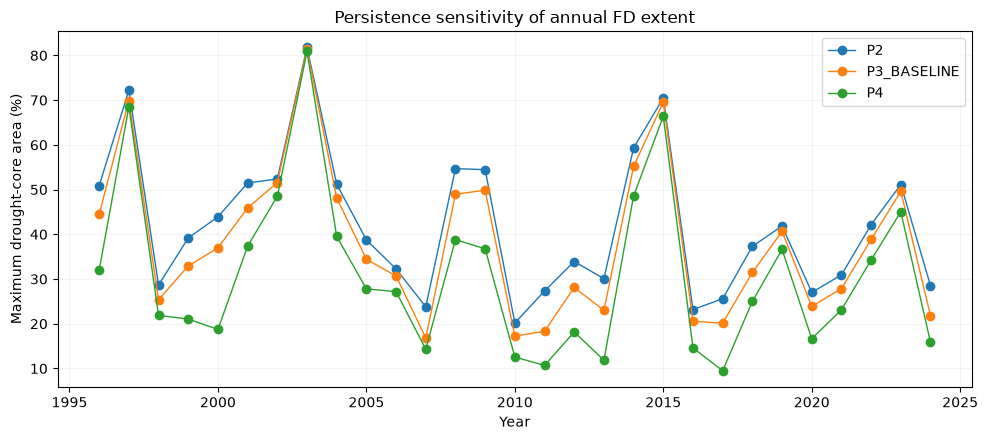

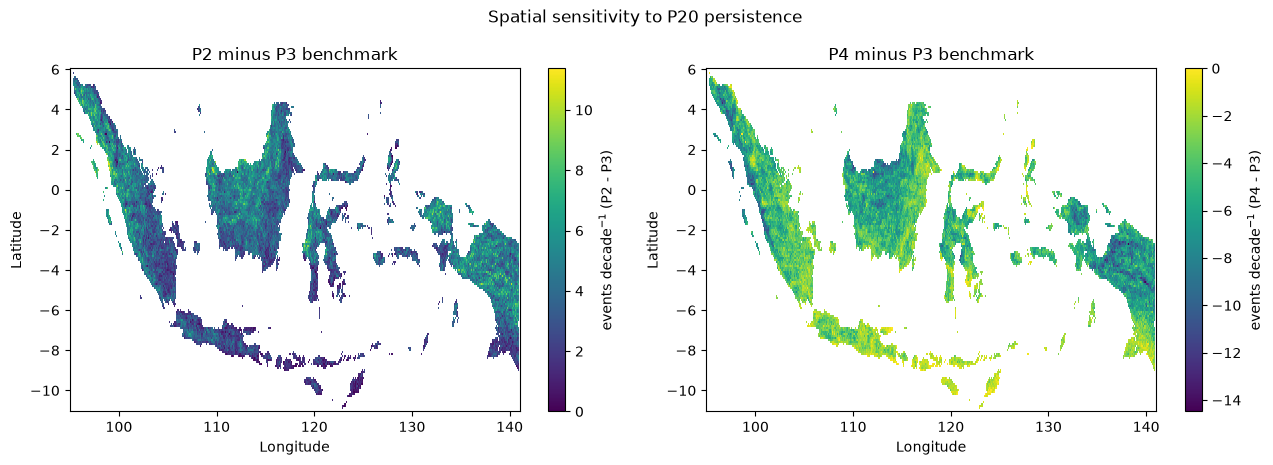

In [6]:
fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

for name, group in annual.groupby(
    "method"
):
    ax.plot(
        group["year"],
        group[
            "maximum_drought_core_area_percent"
        ],
        marker="o",
        linewidth=1,
        label=name,
    )

ax.set(
    xlabel="Year",
    ylabel="Maximum drought-core area (%)",
    title=(
        "Persistence sensitivity of "
        "annual FD extent"
    ),
)

ax.legend()
ax.grid(alpha=0.15)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "figure_persistence_annual_core.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


base_freq = freq_maps[
    "P3_BASELINE"
]

n_years = (
    ANALYSIS_END
    - ANALYSIS_START
    + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.7),
)

for ax, name in zip(
    axes,
    ["P2", "P4"],
):
    diff = (
        (
            freq_maps[name]
            - base_freq
        )
        / n_years
        * 10.0
    )

    im = ax.pcolormesh(
        diff["longitude"],
        diff["latitude"],
        diff.where(valid),
        shading="auto",
    )

    fig.colorbar(
        im,
        ax=ax,
        label=(
            f"events decade$^{{-1}}$ "
            f"({name} - P3)"
        ),
    )

    ax.set(
        xlabel="Longitude",
        ylabel="Latitude",
        title=f"{name} minus P3 benchmark",
    )

fig.suptitle(
    "Spatial sensitivity to P20 persistence"
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "figure_persistence_frequency_differences.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


## Interpretation

Possible scientifically useful outcomes:

- If counts and spatial patterns are both stable → strong robustness.
- If counts change but hotspots/top years remain similar → absolute frequency is sensitive, but the spatial-temporal story is robust.
- If hotspots/top years change strongly → persistence choice is structurally important and must be emphasized as a limitation.


In [7]:
manifest = {
    "test": (
        "initial consecutive persistence "
        "below P20"
    ),
    "variants_pentads": [2, 3, 4],
    "benchmark_pentads": 3,
    "max_onset_pentads": 5,
    "recovery_pentads": 1,
}

(
    OUTPUT_DIR
    / "manifest_03f_persistence_sensitivity.json"
).write_text(
    json.dumps(
        manifest,
        indent=2,
    ),
    encoding="utf-8",
)

for name, ds_method in datasets.items():
    if ds_method is not baseline:
        ds_method.close()

baseline.close()
pct_ds.close()

print(
    "03f complete:",
    OUTPUT_DIR,
)


03f complete: D:\ERA5_LAND\output_fd_03f_persistence_sensitivity
